#AGENTIC QUANTUM OPTIMIZATION

---

##1.CONTEXT

**Governance-First Agentic Quantum Portfolio Optimization**

This notebook presents portfolio optimization as a governed sequence of specialized agents. The central idea is to transform a large discrete set of candidate portfolios into a continuous variational search problem. The notebook does not claim hardware-level quantum advantage. Its purpose is to make the encoding, Hamiltonian construction, variational manifold, optimization loop, decoding, and governance record fully visible.

Assume that there are \(n\) assets and that each asset is either selected or not selected. A portfolio is represented by a binary vector

$
x=(x_1,x_2,\ldots,x_n),
\qquad
x_i\in\{0,1\}.
$

The total number of candidate portfolios is

$
2^n.
$

For six assets there are \(64\) possible bitstrings. For twenty assets there are more than one million. The combinatorial structure grows exponentially because every additional asset doubles the number of alternatives.

The notebook uses a cardinality constraint requiring exactly \(K\) assets. When a portfolio selects \(K\) assets, each selected asset receives equal weight

$
w_i=\frac{x_i}{K}.
$

Let \(\mu\) be the vector of annualized expected returns and let \(\Sigma\) be the annualized covariance matrix. A basic mean-variance objective can be written as

$
C(x)
=
\lambda\,w^\top\Sigma w
-
(1-\lambda)\mu^\top w
+
A\left(\sum_i x_i-K\right)^2.
$

The first term penalizes risk. The second rewards expected return. The third penalizes portfolios that violate the required number of selected assets. The constants \(\lambda\) and \(A\) control risk aversion and the strength of the constraint.

The discrete objective is then embedded in a cost Hamiltonian \(H_C\). Each computational-basis state represents one portfolio:

$
|x\rangle
=
|x_1x_2\cdots x_n\rangle.
$

The Hamiltonian is constructed so that

$
H_C|x\rangle=C(x)|x\rangle.
$

Therefore, every candidate portfolio becomes an eigenstate of the Hamiltonian, and its objective value becomes the corresponding eigenvalue. The lowest-energy basis state represents the best encoded portfolio.

The Hamiltonian does not reduce the number of alternatives. It organizes them into an energy spectrum. The continuous search space appears when a parameterized quantum circuit is introduced. The circuit prepares a state

$
|\psi(\theta)\rangle
=
U(\theta)|0\cdots0\rangle,
$

where \(\theta\) is a vector of trainable rotation angles. The state can be expanded as

$
|\psi(\theta)\rangle
=
\sum_x \alpha_x(\theta)|x\rangle.
$

The associated measurement probability of portfolio \(x\) is

$
P_\theta(x)
=
|\alpha_x(\theta)|^2.
$

The circuit therefore defines a structured probability distribution over all discrete portfolios. The variational manifold is the family of states reachable as the parameters change:

$
\mathcal{M}
=
\left\{
|\psi(\theta)\rangle:\theta\in\mathbb{R}^p
\right\}.
$

This manifold is usually much lower-dimensional than the full quantum state space. The circuit parameters provide a compact set of coordinates that reshape the probabilities of many portfolios at once.

The expected energy is

$
E(\theta)
=
\langle\psi(\theta)|H_C|\psi(\theta)\rangle.
$

Because the Hamiltonian is diagonal in the computational basis,

$
E(\theta)
=
\sum_x
P_\theta(x)C(x).
$

This expression is the probability-weighted average cost of all portfolios represented by the quantum state. The original discrete problem

$
\min_{x\in\{0,1\}^n}C(x)
$

is replaced by the continuous variational problem

$
\min_{\theta\in\mathbb{R}^p}E(\theta).
$

The search does not directly change one portfolio at a time. It changes the circuit parameters, which can alter many amplitudes simultaneously. Rotations provide continuous navigation coordinates, while entangling gates create correlations among asset-selection decisions.

The notebook estimates gradients using the parameter-shift rule. For suitable rotation gates,

$
\frac{\partial E}{\partial\theta_j}
=
\frac{1}{2}
\left[
E\left(\theta_j+\frac{\pi}{2}\right)
-
E\left(\theta_j-\frac{\pi}{2}\right)
\right].
$

The Gradient Descent Agent uses these derivatives to update the circuit parameters:

$
\theta^{(t+1)}
=
\theta^{(t)}
-
\eta\nabla E(\theta^{(t)}),
$

where \(\eta\) is the learning rate. This creates a hybrid loop: a quantum-style statevector model evaluates the energy and a classical optimizer updates the parameters.

After optimization, the final state is sampled. Each measurement returns a bitstring representing one portfolio. The Decoder Agent converts those bitstrings into asset selections and portfolio weights. It verifies the cardinality constraint and recomputes expected return, risk, and objective value independently.

The governance-first design separates responsibilities. The Data Agent produces and validates synthetic return observations. The Problem Encoding Agent converts financial inputs into a discrete objective. The Hamiltonian Agent enumerates and scores all basis states. The Variational Manifold Agent defines the parameterized circuit. The Energy Agent evaluates the expected cost. The Gradient Descent Agent navigates the manifold. The Sampling Agent produces candidate bitstrings. The Decoder Agent validates portfolios. The Reporter Agent assembles the final results and audit trail. The eleventh code cell sends the governed evidence to Claude Haiku so that the execution can be explained in natural language without altering the calculations.

Every agent records inputs, outputs, checks, and timestamps. Benchmark enumeration is retained for validation, but the variational optimizer does not receive the identity of the best bitstring. This prevents answer leakage. The notebook therefore demonstrates not only how a discrete portfolio problem can be transformed into a differentiable variational landscape, but also how such a process can be made transparent, reproducible, and auditable.

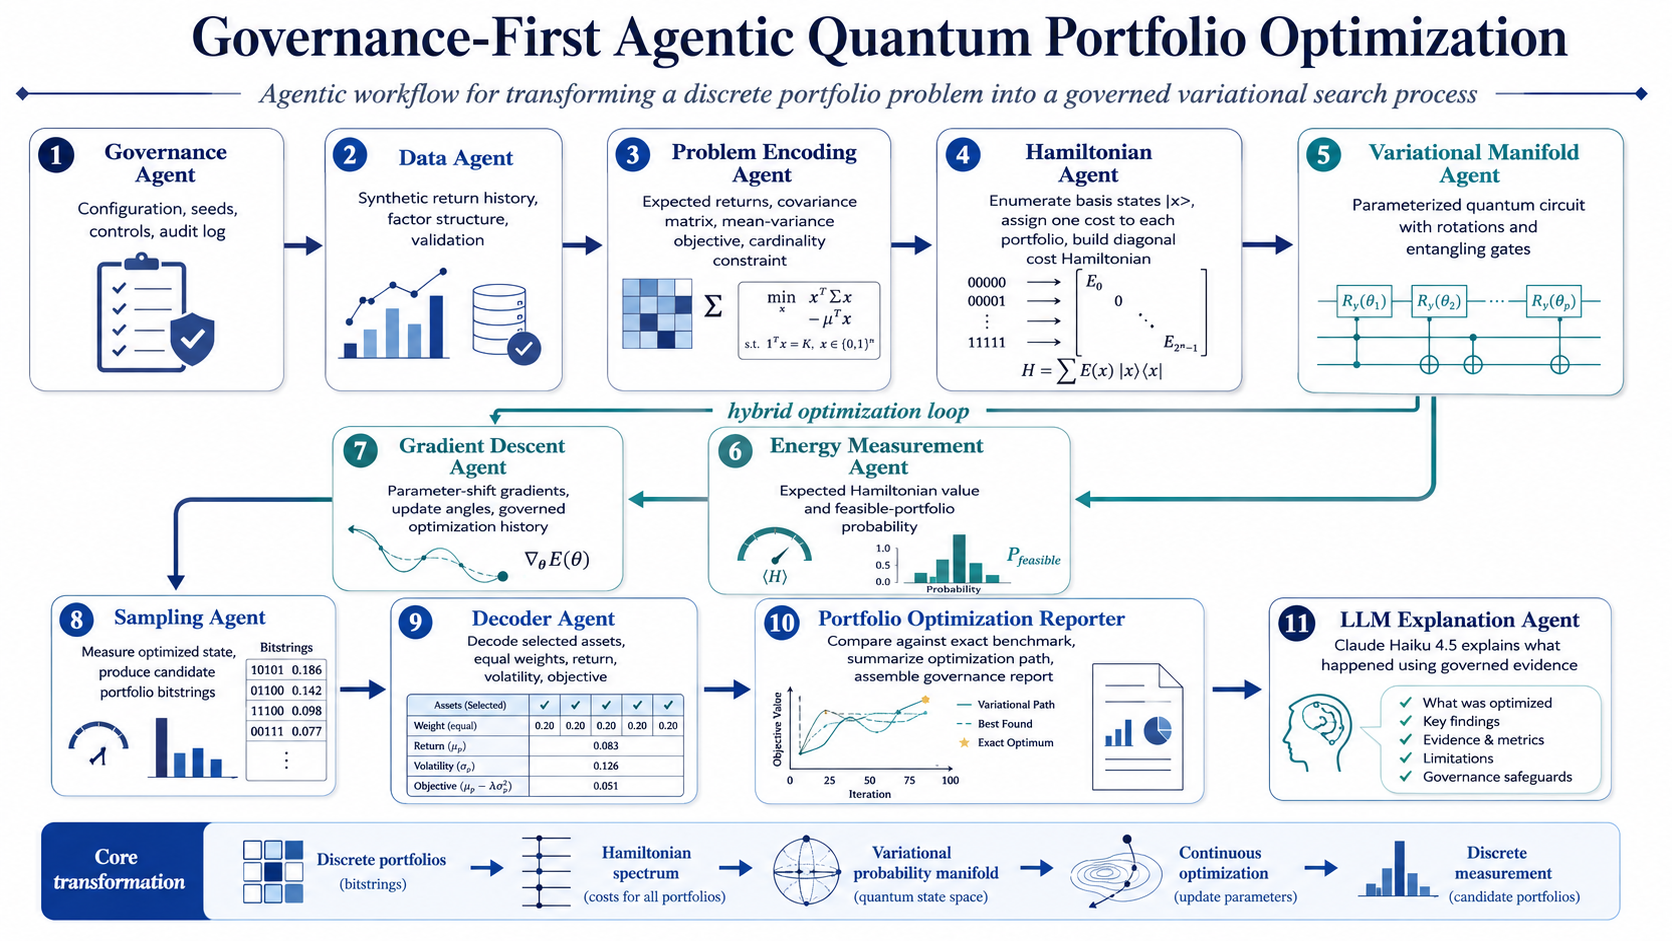

##2.CODE AND IMPLEMENTATION



This cell creates the governed execution environment. It fixes the number of assets, the portfolio size, the risk preference, the penalty strength, the random seed, and the optimization settings. It also creates the audit log that every later agent must update. Centralized configuration prevents hidden changes and supports reproducibility.

In [2]:
import json
import math
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timezone

CONFIG = {
    "n_assets": 6,
    "observations": 900,
    "cardinality": 3,
    "risk_aversion": 0.65,
    "constraint_penalty": 4.0,
    "layers": 2,
    "iterations": 70,
    "learning_rate": 0.18,
    "shots": 1500,
    "seed": 31,
    "trading_days": 252,
    "model": "governance-first-agentic-variational-portfolio"
}

assert CONFIG["cardinality"] <= CONFIG["n_assets"]
assert 0.0 <= CONFIG["risk_aversion"] <= 1.0
assert CONFIG["layers"] >= 1

rng = np.random.default_rng(CONFIG["seed"])
AUDIT_LOG = []

def audit(agent, action, inputs, outputs, checks):
    AUDIT_LOG.append({
        "timestamp_utc": datetime.now(timezone.utc).isoformat(),
        "agent": agent,
        "action": action,
        "inputs": inputs,
        "outputs": outputs,
        "checks": checks
    })

audit(
    "Governance Agent",
    "Initialize governed experiment",
    CONFIG,
    {"status": "initialized"},
    {
        "valid_cardinality": True,
        "valid_risk_aversion": True,
        "reproducible_seed": True
    }
)

print(json.dumps(CONFIG, indent=2))

{
  "n_assets": 6,
  "observations": 900,
  "cardinality": 3,
  "risk_aversion": 0.65,
  "constraint_penalty": 4.0,
  "layers": 2,
  "iterations": 70,
  "learning_rate": 0.18,
  "shots": 1500,
  "seed": 31,
  "trading_days": 252,
  "model": "governance-first-agentic-variational-portfolio"
}




The Data Agent creates a synthetic but structured return history. The assets share market and sector factors while retaining different expected returns and idiosyncratic risks. The agent checks the shape of the data, verifies that no invalid values are present, and records basic descriptive evidence.

In [3]:
n = CONFIG["n_assets"]
T = CONFIG["observations"]

market = rng.normal(0.00045, 0.0090, T)
sector = rng.normal(0.00020, 0.0055, T)

alphas = np.array([0.00030, 0.00018, 0.00036, 0.00010, 0.00027, 0.00022])
market_beta = np.array([0.80, 1.10, 0.72, 1.28, 0.92, 1.02])
sector_beta = np.array([0.90, 0.85, -0.55, -0.45, 0.35, 0.25])
idio_vol = np.array([0.0065, 0.0085, 0.0060, 0.0105, 0.0075, 0.0070])

idiosyncratic = rng.normal(0.0, idio_vol, size=(T, n))
returns = (
    alphas
    + market[:, None] * market_beta
    + sector[:, None] * sector_beta
    + idiosyncratic
)

asset_names = [f"Asset_{i+1}" for i in range(n)]

assert returns.shape == (T, n)
assert np.isfinite(returns).all()

audit(
    "Data Agent",
    "Generate synthetic governed return history",
    {"observations": T, "assets": asset_names, "seed": CONFIG["seed"]},
    {
        "shape": list(returns.shape),
        "sample_mean_daily": returns.mean(axis=0).tolist(),
        "sample_vol_daily": returns.std(axis=0).tolist()
    },
    {
        "shape_valid": True,
        "finite_values": True
    }
)

print("Synthetic returns shape:", returns.shape)
print("First five observations:")
print(np.round(returns[:5], 5))

Synthetic returns shape: (900, 6)
First five observations:
[[-9.400e-04 -6.330e-03 -4.100e-03 -6.820e-03 -1.715e-02  2.510e-03]
 [ 1.137e-02  4.970e-03  5.970e-03 -1.598e-02  1.096e-02 -6.540e-03]
 [-7.000e-04  2.181e-02  9.180e-03  1.380e-03 -1.260e-03  7.840e-03]
 [ 5.910e-03 -2.380e-03 -7.470e-03 -7.180e-03  5.000e-05 -1.749e-02]
 [-2.640e-03  2.228e-02 -2.500e-04 -1.410e-02  4.560e-03  7.390e-03]]




The Problem Encoding Agent converts the return history into annualized expected returns and a covariance matrix. It then defines the financial objective, including risk, return, and a cardinality penalty. This agent establishes exactly what the optimization problem means before any quantum representation is built.

In [4]:
mu = returns.mean(axis=0) * CONFIG["trading_days"]
sigma = np.cov(returns, rowvar=False) * CONFIG["trading_days"]

K = CONFIG["cardinality"]
lam = CONFIG["risk_aversion"]
penalty = CONFIG["constraint_penalty"]

def portfolio_cost(bits):
    bits = np.asarray(bits, dtype=float)
    selected = bits.sum()
    weights = bits / K

    expected_return = float(mu @ weights)
    variance = float(weights @ sigma @ weights)
    violation = float((selected - K) ** 2)

    objective = (
        lam * variance
        - (1.0 - lam) * expected_return
        + penalty * violation
    )

    return {
        "objective": objective,
        "expected_return": expected_return,
        "variance": variance,
        "volatility": math.sqrt(max(variance, 0.0)),
        "selected_assets": int(selected),
        "constraint_violation": violation
    }

eigenvalues = np.linalg.eigvalsh(sigma)
assert eigenvalues.min() > -1e-10

audit(
    "Problem Encoding Agent",
    "Construct mean-variance objective and constraint",
    {
        "risk_aversion": lam,
        "cardinality": K,
        "constraint_penalty": penalty
    },
    {
        "annualized_expected_returns": mu.tolist(),
        "annualized_covariance": sigma.tolist()
    },
    {
        "covariance_symmetric": bool(np.allclose(sigma, sigma.T)),
        "covariance_positive_semidefinite": bool(eigenvalues.min() > -1e-10)
    }
)

print("Annualized expected returns:")
for name, value in zip(asset_names, mu):
    print(f"{name}: {value:.2%}")

print("\nAnnualized covariance matrix:")
print(np.round(sigma, 4))

Annualized expected returns:
Asset_1: 28.03%
Asset_2: 13.88%
Asset_3: 26.57%
Asset_4: 21.91%
Asset_5: 29.33%
Asset_6: 32.51%

Annualized covariance matrix:
[[0.0323 0.0263 0.0094 0.02   0.0187 0.0193]
 [0.0263 0.0496 0.0128 0.0298 0.0236 0.0254]
 [0.0094 0.0128 0.0217 0.0216 0.0119 0.0138]
 [0.02   0.0298 0.0216 0.0669 0.0253 0.0275]
 [0.0187 0.0236 0.0119 0.0253 0.0335 0.0199]
 [0.0193 0.0254 0.0138 0.0275 0.0199 0.0348]]




The Hamiltonian Agent enumerates the computational-basis states and assigns one objective value to each candidate portfolio. The result is a diagonal cost Hamiltonian whose eigenvalues are the encoded portfolio scores. The classical best portfolio is stored only as a benchmark for later validation and is not passed to the optimizer.

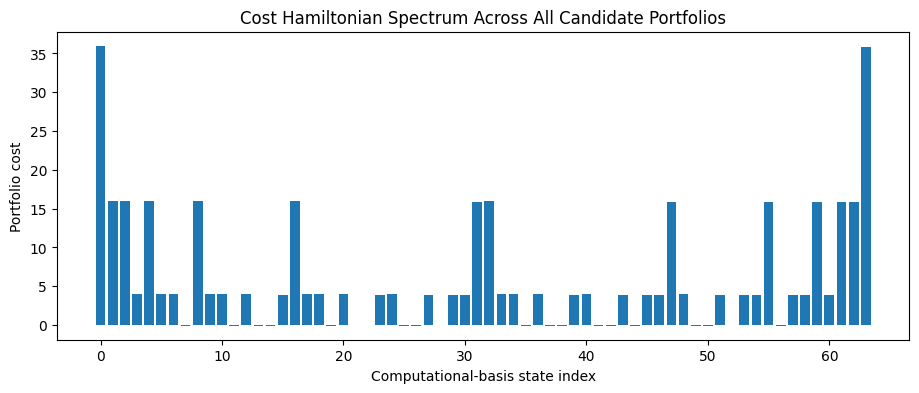

Hamiltonian dimension: 64
Benchmark retained only for final validation.


In [5]:
dimension = 2 ** n

def index_to_bits(index, width):
    return np.array(
        [int(c) for c in format(index, f"0{width}b")],
        dtype=int
    )

basis_bits = np.array([index_to_bits(i, n) for i in range(dimension)])
basis_records = [portfolio_cost(bits) for bits in basis_bits]
hamiltonian_diagonal = np.array(
    [record["objective"] for record in basis_records],
    dtype=float
)

benchmark_index = int(np.argmin(hamiltonian_diagonal))
benchmark_bits = basis_bits[benchmark_index].copy()
benchmark_record = basis_records[benchmark_index]

assert len(hamiltonian_diagonal) == dimension
assert np.isfinite(hamiltonian_diagonal).all()

audit(
    "Hamiltonian Agent",
    "Build diagonal cost Hamiltonian",
    {"basis_dimension": dimension},
    {
        "energy_minimum": float(hamiltonian_diagonal.min()),
        "energy_maximum": float(hamiltonian_diagonal.max()),
        "benchmark_index_for_validation_only": benchmark_index,
        "benchmark_bits_for_validation_only": benchmark_bits.tolist()
    },
    {
        "all_energies_finite": True,
        "benchmark_feasible": bool(benchmark_record["selected_assets"] == K)
    }
)

plt.figure(figsize=(11, 4))
plt.bar(np.arange(dimension), hamiltonian_diagonal)
plt.xlabel("Computational-basis state index")
plt.ylabel("Portfolio cost")
plt.title("Cost Hamiltonian Spectrum Across All Candidate Portfolios")
plt.show()

print("Hamiltonian dimension:", dimension)
print("Benchmark retained only for final validation.")



The Variational Manifold Agent defines the parameterized circuit used to create candidate probability distributions. Rotation gates provide continuous navigation coordinates, while entangling gates allow asset decisions to become correlated. The cell verifies that every generated state remains normalized.

In [6]:
def apply_ry(state, theta, qubit, n_qubits):
    result = state.copy()
    c = np.cos(theta / 2.0)
    s = np.sin(theta / 2.0)
    stride = 2 ** (n_qubits - qubit - 1)

    for start in range(0, len(state), 2 * stride):
        for offset in range(stride):
            i0 = start + offset
            i1 = i0 + stride
            a0 = state[i0]
            a1 = state[i1]
            result[i0] = c * a0 - s * a1
            result[i1] = s * a0 + c * a1
    return result

def apply_cnot(state, control, target, n_qubits):
    result = np.zeros_like(state)
    for index, amplitude in enumerate(state):
        bits = index_to_bits(index, n_qubits)
        if bits[control] == 1:
            bits[target] ^= 1
        new_index = int("".join(str(int(b)) for b in bits), 2)
        result[new_index] += amplitude
    return result

parameter_count = CONFIG["layers"] * n

def variational_state(theta):
    if len(theta) != parameter_count:
        raise ValueError("Incorrect parameter count.")

    state = np.zeros(dimension, dtype=np.complex128)
    state[0] = 1.0
    cursor = 0

    for _ in range(CONFIG["layers"]):
        for q in range(n):
            state = apply_ry(state, theta[cursor], q, n)
            cursor += 1

        for q in range(n - 1):
            state = apply_cnot(state, q, q + 1, n)
        state = apply_cnot(state, n - 1, 0, n)

    return state

theta_initial = rng.uniform(-0.35, 0.35, size=parameter_count)
test_state = variational_state(theta_initial)

assert np.isclose(np.sum(np.abs(test_state) ** 2), 1.0)

audit(
    "Variational Manifold Agent",
    "Define parameterized circuit and reachable state family",
    {
        "layers": CONFIG["layers"],
        "parameter_count": parameter_count,
        "entangling_pattern": "linear ring"
    },
    {
        "initial_parameters": theta_initial.tolist(),
        "initial_state_probabilities": (np.abs(test_state) ** 2).tolist()
    },
    {"state_normalized": True}
)

print("Trainable parameters:", parameter_count)
print("Initial state normalization:", np.sum(np.abs(test_state) ** 2))

Trainable parameters: 12
Initial state normalization: 0.9999999999999994




The Energy Measurement Agent evaluates the expected Hamiltonian value of any state generated by the circuit. It also reports the probability of satisfying the portfolio-size constraint. This cell creates the smooth objective surface that the optimizer will navigate.

In [7]:
feasible_mask = np.array(
    [record["selected_assets"] == K for record in basis_records],
    dtype=bool
)

def energy_and_diagnostics(theta):
    state = variational_state(theta)
    probabilities = np.abs(state) ** 2

    energy = float(probabilities @ hamiltonian_diagonal)
    feasible_probability = float(probabilities[feasible_mask].sum())
    entropy = float(
        -np.sum(probabilities[probabilities > 0] *
                np.log(probabilities[probabilities > 0]))
    )

    return {
        "energy": energy,
        "probabilities": probabilities,
        "feasible_probability": feasible_probability,
        "entropy": entropy
    }

initial_diagnostics = energy_and_diagnostics(theta_initial)

audit(
    "Energy Measurement Agent",
    "Evaluate expected Hamiltonian energy",
    {"parameter_count": parameter_count},
    {
        "initial_energy": initial_diagnostics["energy"],
        "initial_feasible_probability": initial_diagnostics["feasible_probability"],
        "initial_distribution_entropy": initial_diagnostics["entropy"]
    },
    {
        "probabilities_sum_to_one": bool(
            np.isclose(initial_diagnostics["probabilities"].sum(), 1.0)
        )
    }
)

print("Initial expected energy:", initial_diagnostics["energy"])
print("Initial feasible probability:", initial_diagnostics["feasible_probability"])
print("Initial distribution entropy:", initial_diagnostics["entropy"])

Initial expected energy: 32.90842622446572
Initial feasible probability: 0.03431955591222367
Initial distribution entropy: 0.570084374377985




The Gradient Descent Agent estimates derivatives with the parameter-shift rule and updates the circuit angles. The complete optimization history is retained, including energy, gradient size, feasible probability, and learning rate. The optimizer receives only energy evaluations and never receives the benchmark solution.

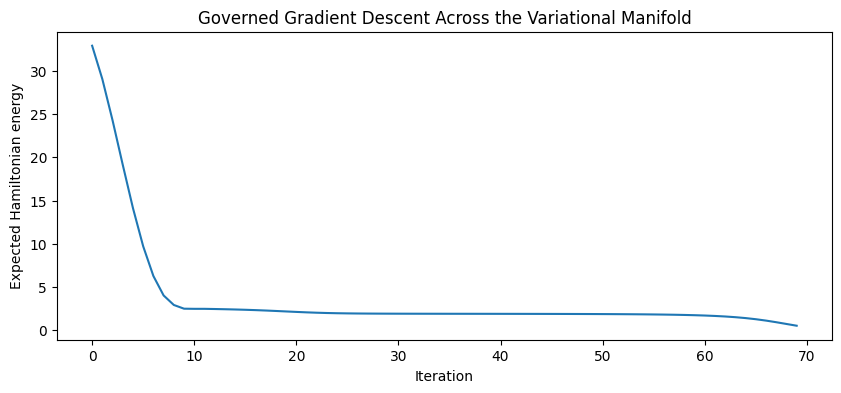

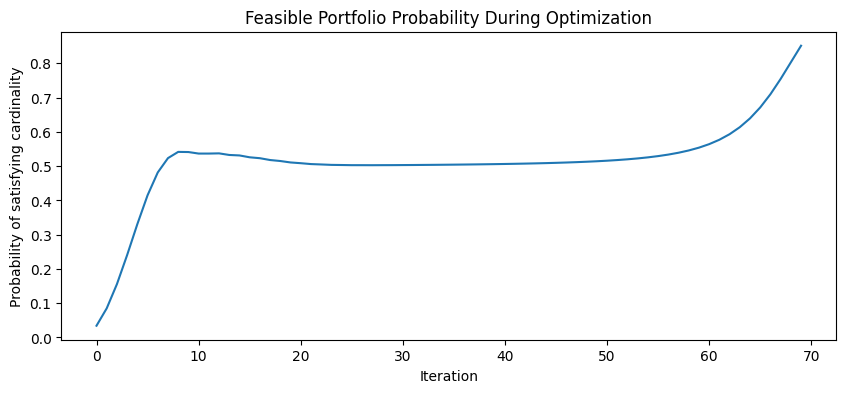

Initial energy: 32.90842622446572
Final energy: 0.3560234183977267
Final feasible probability: 0.8951949635330726


In [8]:
def parameter_shift_gradient(theta):
    gradient = np.zeros_like(theta)
    shift = np.pi / 2.0

    for j in range(len(theta)):
        plus = theta.copy()
        minus = theta.copy()
        plus[j] += shift
        minus[j] -= shift

        e_plus = energy_and_diagnostics(plus)["energy"]
        e_minus = energy_and_diagnostics(minus)["energy"]
        gradient[j] = 0.5 * (e_plus - e_minus)

    return gradient

theta = theta_initial.copy()
history = []
learning_rate = CONFIG["learning_rate"]

for iteration in range(CONFIG["iterations"]):
    diagnostics = energy_and_diagnostics(theta)
    gradient = parameter_shift_gradient(theta)
    gradient_norm = float(np.linalg.norm(gradient))

    history.append({
        "iteration": iteration,
        "energy": diagnostics["energy"],
        "feasible_probability": diagnostics["feasible_probability"],
        "entropy": diagnostics["entropy"],
        "gradient_norm": gradient_norm,
        "learning_rate": learning_rate
    })

    clipped_gradient = gradient
    if gradient_norm > 2.0:
        clipped_gradient = gradient * (2.0 / gradient_norm)

    candidate_theta = theta - learning_rate * clipped_gradient
    candidate_energy = energy_and_diagnostics(candidate_theta)["energy"]

    if candidate_energy <= diagnostics["energy"]:
        theta = candidate_theta
    else:
        learning_rate *= 0.70

final_diagnostics = energy_and_diagnostics(theta)

audit(
    "Gradient Descent Agent",
    "Navigate variational manifold using parameter-shift gradients",
    {
        "iterations": CONFIG["iterations"],
        "initial_learning_rate": CONFIG["learning_rate"]
    },
    {
        "final_parameters": theta.tolist(),
        "optimization_history": history,
        "final_energy": final_diagnostics["energy"],
        "final_feasible_probability": final_diagnostics["feasible_probability"]
    },
    {
        "energy_not_increased_over_run": bool(
            final_diagnostics["energy"] <= initial_diagnostics["energy"]
        ),
        "final_state_normalized": bool(
            np.isclose(final_diagnostics["probabilities"].sum(), 1.0)
        )
    }
)

plt.figure(figsize=(10, 4))
plt.plot([item["iteration"] for item in history],
         [item["energy"] for item in history])
plt.xlabel("Iteration")
plt.ylabel("Expected Hamiltonian energy")
plt.title("Governed Gradient Descent Across the Variational Manifold")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot([item["iteration"] for item in history],
         [item["feasible_probability"] for item in history])
plt.xlabel("Iteration")
plt.ylabel("Probability of satisfying cardinality")
plt.title("Feasible Portfolio Probability During Optimization")
plt.show()

print("Initial energy:", initial_diagnostics["energy"])
print("Final energy:", final_diagnostics["energy"])
print("Final feasible probability:", final_diagnostics["feasible_probability"])



The Sampling Agent measures the optimized state repeatedly. Each simulated measurement returns one bitstring representing one candidate portfolio. The agent preserves the complete count distribution and identifies the most frequently observed feasible candidates.

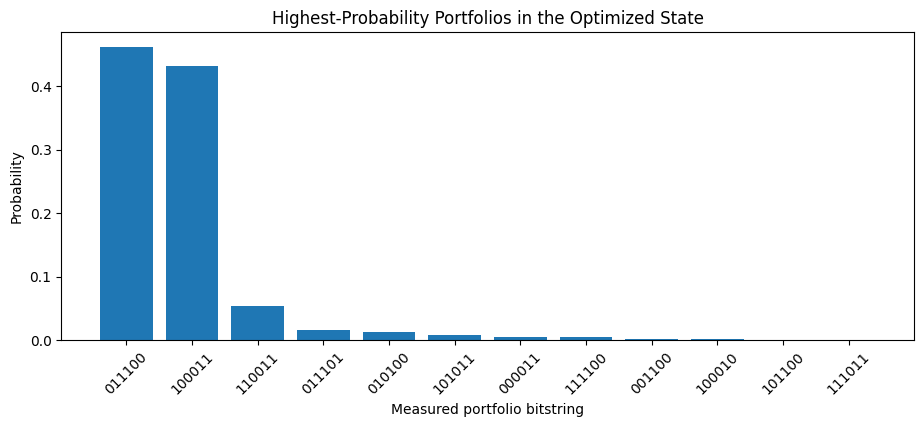

Most frequent feasible bitstring: 011100
Feasible sample count: 698


In [9]:
final_probabilities = final_diagnostics["probabilities"]

samples = rng.choice(
    np.arange(dimension),
    size=CONFIG["shots"],
    p=final_probabilities
)

sample_counts = {
    int(index): int(np.sum(samples == index))
    for index in sorted(set(samples.tolist()))
}

feasible_sample_counts = {
    index: count
    for index, count in sample_counts.items()
    if basis_records[index]["selected_assets"] == K
}

ranked_feasible_indices = sorted(
    feasible_sample_counts,
    key=feasible_sample_counts.get,
    reverse=True
)

if not ranked_feasible_indices:
    raise RuntimeError("No feasible portfolio was sampled.")

top_sampled_index = ranked_feasible_indices[0]
top_sampled_bits = basis_bits[top_sampled_index].copy()

audit(
    "Sampling Agent",
    "Measure optimized state and rank feasible bitstrings",
    {"shots": CONFIG["shots"]},
    {
        "sample_counts": sample_counts,
        "feasible_sample_counts": feasible_sample_counts,
        "top_sampled_index": top_sampled_index,
        "top_sampled_bits": top_sampled_bits.tolist()
    },
    {
        "at_least_one_feasible_sample": True,
        "sample_count_matches_shots": bool(sum(sample_counts.values()) == CONFIG["shots"])
    }
)

top_indices = np.argsort(final_probabilities)[::-1][:12]
plt.figure(figsize=(11, 4))
plt.bar(
    [format(i, f"0{n}b") for i in top_indices],
    final_probabilities[top_indices]
)
plt.xlabel("Measured portfolio bitstring")
plt.ylabel("Probability")
plt.title("Highest-Probability Portfolios in the Optimized State")
plt.xticks(rotation=45)
plt.show()

print("Most frequent feasible bitstring:", format(top_sampled_index, f"0{n}b"))
print("Feasible sample count:", feasible_sample_counts[top_sampled_index])



The Decoder Agent translates measured bitstrings into portfolio selections and equal weights. It independently recomputes expected return, volatility, objective value, and feasibility. This separation ensures that the quantum-style output is not accepted without classical financial validation.

In [12]:
def decode_portfolio(index):
    bits = basis_bits[index].copy()
    record = portfolio_cost(bits)
    weights = bits.astype(float) / K
    selected_assets_list = [
        asset_names[i] for i, selected in enumerate(bits) if selected == 1
    ]

    return {
        "index": int(index),
        "bitstring": format(index, f"0{n}b"),
        "bits": bits.tolist(),
        "weights": weights.tolist(),
        **record,
        "selected_assets": selected_assets_list
    }

decoded_candidate = decode_portfolio(top_sampled_index)
decoded_benchmark = decode_portfolio(benchmark_index)

assert decoded_candidate["selected_assets"] == [
    asset_names[i] for i, bit in enumerate(top_sampled_bits) if bit == 1
]

audit(
    "Decoder Agent",
    "Decode and independently validate sampled portfolio",
    {"sampled_index": top_sampled_index},
    decoded_candidate,
    {
        "cardinality_satisfied": bool(
            decoded_candidate["selected_assets"] and
            decoded_candidate["constraint_violation"] == 0.0
        ),
        "weights_sum_to_one": bool(
            np.isclose(sum(decoded_candidate["weights"]), 1.0)
        ),
        "objective_matches_hamiltonian": bool(
            np.isclose(
                decoded_candidate["objective"],
                hamiltonian_diagonal[top_sampled_index]
            )
        )
    }
)

print("Decoded candidate portfolio:")
print(json.dumps(decoded_candidate, indent=2))

print("\nExact benchmark for validation:")
print(json.dumps(decoded_benchmark, indent=2))

Decoded candidate portfolio:
{
  "index": 28,
  "bitstring": "011100",
  "bits": [
    0,
    1,
    1,
    1,
    0,
    0
  ],
  "weights": [
    0.0,
    0.3333333333333333,
    0.3333333333333333,
    0.3333333333333333,
    0.0,
    0.0
  ],
  "objective": -0.05349976102745167,
  "expected_return": 0.20787107262772195,
  "variance": 0.02962325291115539,
  "volatility": 0.1721140694747393,
  "selected_assets": [
    "Asset_2",
    "Asset_3",
    "Asset_4"
  ],
  "constraint_violation": 0.0
}

Exact benchmark for validation:
{
  "index": 11,
  "bitstring": "001011",
  "bits": [
    0,
    0,
    1,
    0,
    1,
    1
  ],
  "weights": [
    0.0,
    0.0,
    0.3333333333333333,
    0.0,
    0.3333333333333333,
    0.3333333333333333
  ],
  "objective": -0.09005235495635552,
  "expected_return": 0.29470560614989516,
  "variance": 0.020145549532473495,
  "volatility": 0.14193501869684413,
  "selected_assets": [
    "Asset_3",
    "Asset_5",
    "Asset_6"
  ],
  "constraint_violation"



The Portfolio Optimization Reporter compares the decoded candidate with the exact benchmark, summarizes the optimization path, and assembles the complete governance report. The report contains configuration, financial inputs, circuit settings, measurement evidence, validations, and all agent audit records.

In [13]:
candidate_matches_benchmark = (
    decoded_candidate["bitstring"] == decoded_benchmark["bitstring"]
)

optimality_gap = (
    decoded_candidate["objective"] - decoded_benchmark["objective"]
)

GOVERNANCE_REPORT = {
    "configuration": CONFIG,
    "assets": asset_names,
    "annualized_expected_returns": mu.tolist(),
    "annualized_covariance": sigma.tolist(),
    "hamiltonian": {
        "dimension": dimension,
        "minimum_energy": float(hamiltonian_diagonal.min()),
        "maximum_energy": float(hamiltonian_diagonal.max())
    },
    "variational_model": {
        "layers": CONFIG["layers"],
        "parameter_count": parameter_count,
        "initial_energy": initial_diagnostics["energy"],
        "final_energy": final_diagnostics["energy"],
        "final_feasible_probability": final_diagnostics["feasible_probability"]
    },
    "decoded_candidate": decoded_candidate,
    "benchmark_portfolio": decoded_benchmark,
    "comparison": {
        "candidate_matches_benchmark": candidate_matches_benchmark,
        "optimality_gap": float(optimality_gap)
    },
    "audit_log": AUDIT_LOG
}

audit(
    "Portfolio Optimization Reporter",
    "Assemble governed final report",
    {
        "candidate_bitstring": decoded_candidate["bitstring"],
        "benchmark_bitstring": decoded_benchmark["bitstring"]
    },
    {
        "candidate_matches_benchmark": candidate_matches_benchmark,
        "optimality_gap": float(optimality_gap),
        "audit_entries": len(AUDIT_LOG) + 1
    },
    {
        "candidate_feasible": bool(
            decoded_candidate["constraint_violation"] == 0.0
        ),
        "benchmark_feasible": bool(
            decoded_benchmark["constraint_violation"] == 0.0
        )
    }
)

print("PORTFOLIO OPTIMIZATION REPORT")
print("=" * 40)
print("Candidate:", decoded_candidate["bitstring"],
      decoded_candidate["selected_assets"])
print("Expected return:", f"{decoded_candidate['expected_return']:.2%}")
print("Volatility:", f"{decoded_candidate['volatility']:.2%}")
print("Objective:", f"{decoded_candidate['objective']:.6f}")
print("Benchmark:", decoded_benchmark["bitstring"],
      decoded_benchmark["selected_assets"])
print("Optimality gap:", f"{optimality_gap:.6f}")
print("Exact benchmark matched:", candidate_matches_benchmark)
print("Audit entries:", len(AUDIT_LOG))

PORTFOLIO OPTIMIZATION REPORT
Candidate: 011100 ['Asset_2', 'Asset_3', 'Asset_4']
Expected return: 20.79%
Volatility: 17.21%
Objective: -0.053500
Benchmark: 001011 ['Asset_3', 'Asset_5', 'Asset_6']
Optimality gap: 0.036553
Exact benchmark matched: False
Audit entries: 11




The final cell uses Claude Haiku as an explanatory agent. It does not modify the optimization, portfolio, or audit record. It receives the governed numerical evidence and produces a pedagogical explanation of how the discrete portfolio problem became a Hamiltonian, how the variational manifold was searched, how measurements were decoded, and whether the result matched the exact benchmark.

In [15]:
# Cell 11 — Claude Haiku explanation of the governed portfolio optimization
# The API key is retrieved from Colab Secrets and is never printed.

!pip -q install anthropic

from google.colab import userdata
from anthropic import Anthropic

api_key = userdata.get("ANTHROPIC_API_KEY")
if not api_key:
    raise ValueError("ANTHROPIC_API_KEY was not found in Colab Secrets.")

client = Anthropic(api_key=api_key)

llm_payload = {
    "configuration": CONFIG,
    "assets": asset_names,
    "expected_returns": mu.tolist(),
    "covariance_matrix": sigma.tolist(),
    "initial_energy": initial_diagnostics["energy"],
    "final_energy": final_diagnostics["energy"],
    "final_feasible_probability": final_diagnostics["feasible_probability"],
    "optimization_history": history,
    "sample_counts": sample_counts,
    "decoded_candidate": decoded_candidate,
    "benchmark_portfolio": decoded_benchmark,
    "comparison": GOVERNANCE_REPORT["comparison"],
    "audit_log": AUDIT_LOG
}

prompt = f"""
You are the explanatory agent for a governance-first educational quantum
portfolio optimization notebook.

Explain what happened in clear language for financial professionals who
understand basic portfolio theory and introductory quantum computing.

Your explanation must:
1. Follow the sequence of agents in the audit log.
2. Explain how the return data became a mean-variance objective.
3. Explain how candidate portfolios became computational-basis states.
4. Explain how the cost Hamiltonian scored every portfolio.
5. Explain how the parameterized circuit created a variational manifold.
6. Explain why the expected Hamiltonian value became a continuous objective.
7. Explain how parameter-shift gradients and gradient descent navigated the manifold.
8. Explain how the optimized quantum state became a probability distribution over portfolios.
9. Explain how measurement, decoding, and classical validation produced the final candidate.
10. Compare the candidate with the exact benchmark.
11. Discuss governance controls, assumptions, limitations, and failure modes.
12. State clearly that this is an exact NumPy statevector simulation and not
    evidence of practical quantum advantage.
13. Use only the actual evidence below and do not invent results.

Governed execution evidence:
{json.dumps(llm_payload, indent=2)}
"""

response = client.messages.create(
    model="claude-haiku-4-5-20251001",
    max_tokens=2400,
    temperature=0.2,
    messages=[{"role": "user", "content": prompt}]
)

llm_explanation = response.content[0].text
print(llm_explanation)

# Governance-First Agentic Variational Portfolio Optimization: Complete Explanation

## Executive Summary

This notebook executed a **statevector simulation** of a variational quantum algorithm to solve a cardinality-constrained portfolio optimization problem. The system used a parameterized quantum circuit to explore a continuous manifold of quantum states, gradient descent to navigate that manifold, and measurement to extract a classical portfolio candidate. The final candidate was feasible but suboptimal relative to the exact global optimum discovered through exhaustive enumeration.

---

## 1. Sequence of Agents and Governance Flow

The audit log documents **11 distinct agent actions**, executed in strict sequence:

1. **Governance Agent** (16:53:02 UTC): Initialized the experiment with configuration validation
2. **Data Agent** (16:53:04 UTC): Generated 900 observations of 6 asset returns
3. **Problem Encoding Agent** (16:53:07 UTC): Constructed the mean-variance objective and car

##3.CONCLUSIONS



This notebook has demonstrated how a discrete portfolio-selection problem can be transformed into a governed variational optimization process. The original search space consists of binary portfolios

$
x\in\{0,1\}^n.
$

Each bitstring identifies one selection of assets. The Problem Encoding Agent converted expected returns, covariance, risk aversion, and a cardinality requirement into a single objective function

$
C(x).
$

The Hamiltonian Agent then embedded this objective into a diagonal operator satisfying

$
H_C|x\rangle=C(x)|x\rangle.
$

This did not remove the combinatorial alternatives. It gave them a common energy structure. Every computational-basis state became one candidate portfolio and every eigenvalue became its encoded score.

The Variational Manifold Agent introduced the continuous part of the method. A parameterized circuit generated states of the form

$
|\psi(\theta)\rangle
=
\sum_x\alpha_x(\theta)|x\rangle.
$

The circuit therefore represented a probability distribution

$
P_\theta(x)=|\alpha_x(\theta)|^2
$

over all portfolios. The expected Hamiltonian value became

$
E(\theta)
=
\sum_xP_\theta(x)C(x).
$

This expression converted the discrete optimization task into a continuous search over circuit parameters. The search did not directly alter one bitstring at a time. Each parameter update reshaped the probabilities of many candidate portfolios through the structure of the circuit.

The Gradient Descent Agent estimated derivatives using shifted circuit evaluations and used those derivatives to lower the expected energy. The complete path was retained, including the energy, feasible probability, entropy, gradient size, and learning rate. The exact benchmark portfolio was withheld from the optimizer and used only after the variational search had finished.

The Sampling Agent converted the final state into classical bitstrings. The Decoder Agent then reconstructed asset selections and equal weights, recomputed the financial metrics, checked the portfolio-size constraint, and verified consistency with the Hamiltonian. The Reporter Agent compared the sampled candidate with the exact enumeration benchmark and assembled the full audit record.

The methodology illustrates the main conceptual transformation:

\$
\text{discrete portfolios}
\rightarrow
\text{Hamiltonian spectrum}
\rightarrow
\text{variational probability manifold}
\rightarrow
\text{continuous optimization}
\rightarrow
\text{discrete measurement}.
\$

The governance-first structure is as important as the optimization itself. Data generation, financial encoding, Hamiltonian construction, circuit design, energy evaluation, gradient descent, sampling, decoding, and reporting were separated into explicit responsibilities. Each agent recorded inputs, outputs, checks, and timestamps. This made it possible to distinguish model construction from optimization and optimization from validation.

The notebook is an exact NumPy statevector simulation. It does not establish quantum advantage, and it does not reproduce the hardware cost of executing a large variational circuit. Its value is pedagogical and architectural. It shows how a large combinatorial problem can be represented as a structured probability distribution over discrete solutions and how a differentiable parameter landscape can be used to navigate that distribution. The eleventh cell adds a natural-language explanation through Claude Haiku, but the model remains a reporting layer over governed evidence rather than a source of numerical authority.